<a href="https://colab.research.google.com/github/jamilhossain2000/CWRU-bearing-fault-classification-ML/blob/main/Cancer_detection_with_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [298]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# importing essential tools from sklearn

from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

# EDA

In [299]:
cancer = pd.read_csv('Cancer_Data.csv')
cancer.head(10)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [300]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [301]:
cancer.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [302]:
cancer['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


/tmp/ipykernel_27369/91456901.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=cancer, palette='hls')


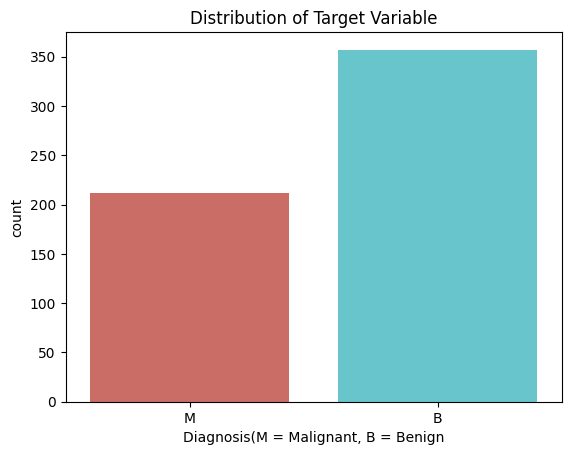

In [303]:
sns.countplot(x='diagnosis', data=cancer, palette='hls')
plt.title('Distribution of Target Variable')
plt.xlabel('Diagnosis(M = Malignant, B = Benign')
plt.show()

In [304]:
cancer=cancer.drop(['id', 'Unnamed: 32'], axis=1)
cancer.head(1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


In [305]:
label_en = LabelEncoder()
cancer['diagnosis'] = label_en.fit_transform(cancer['diagnosis'])
cancer.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


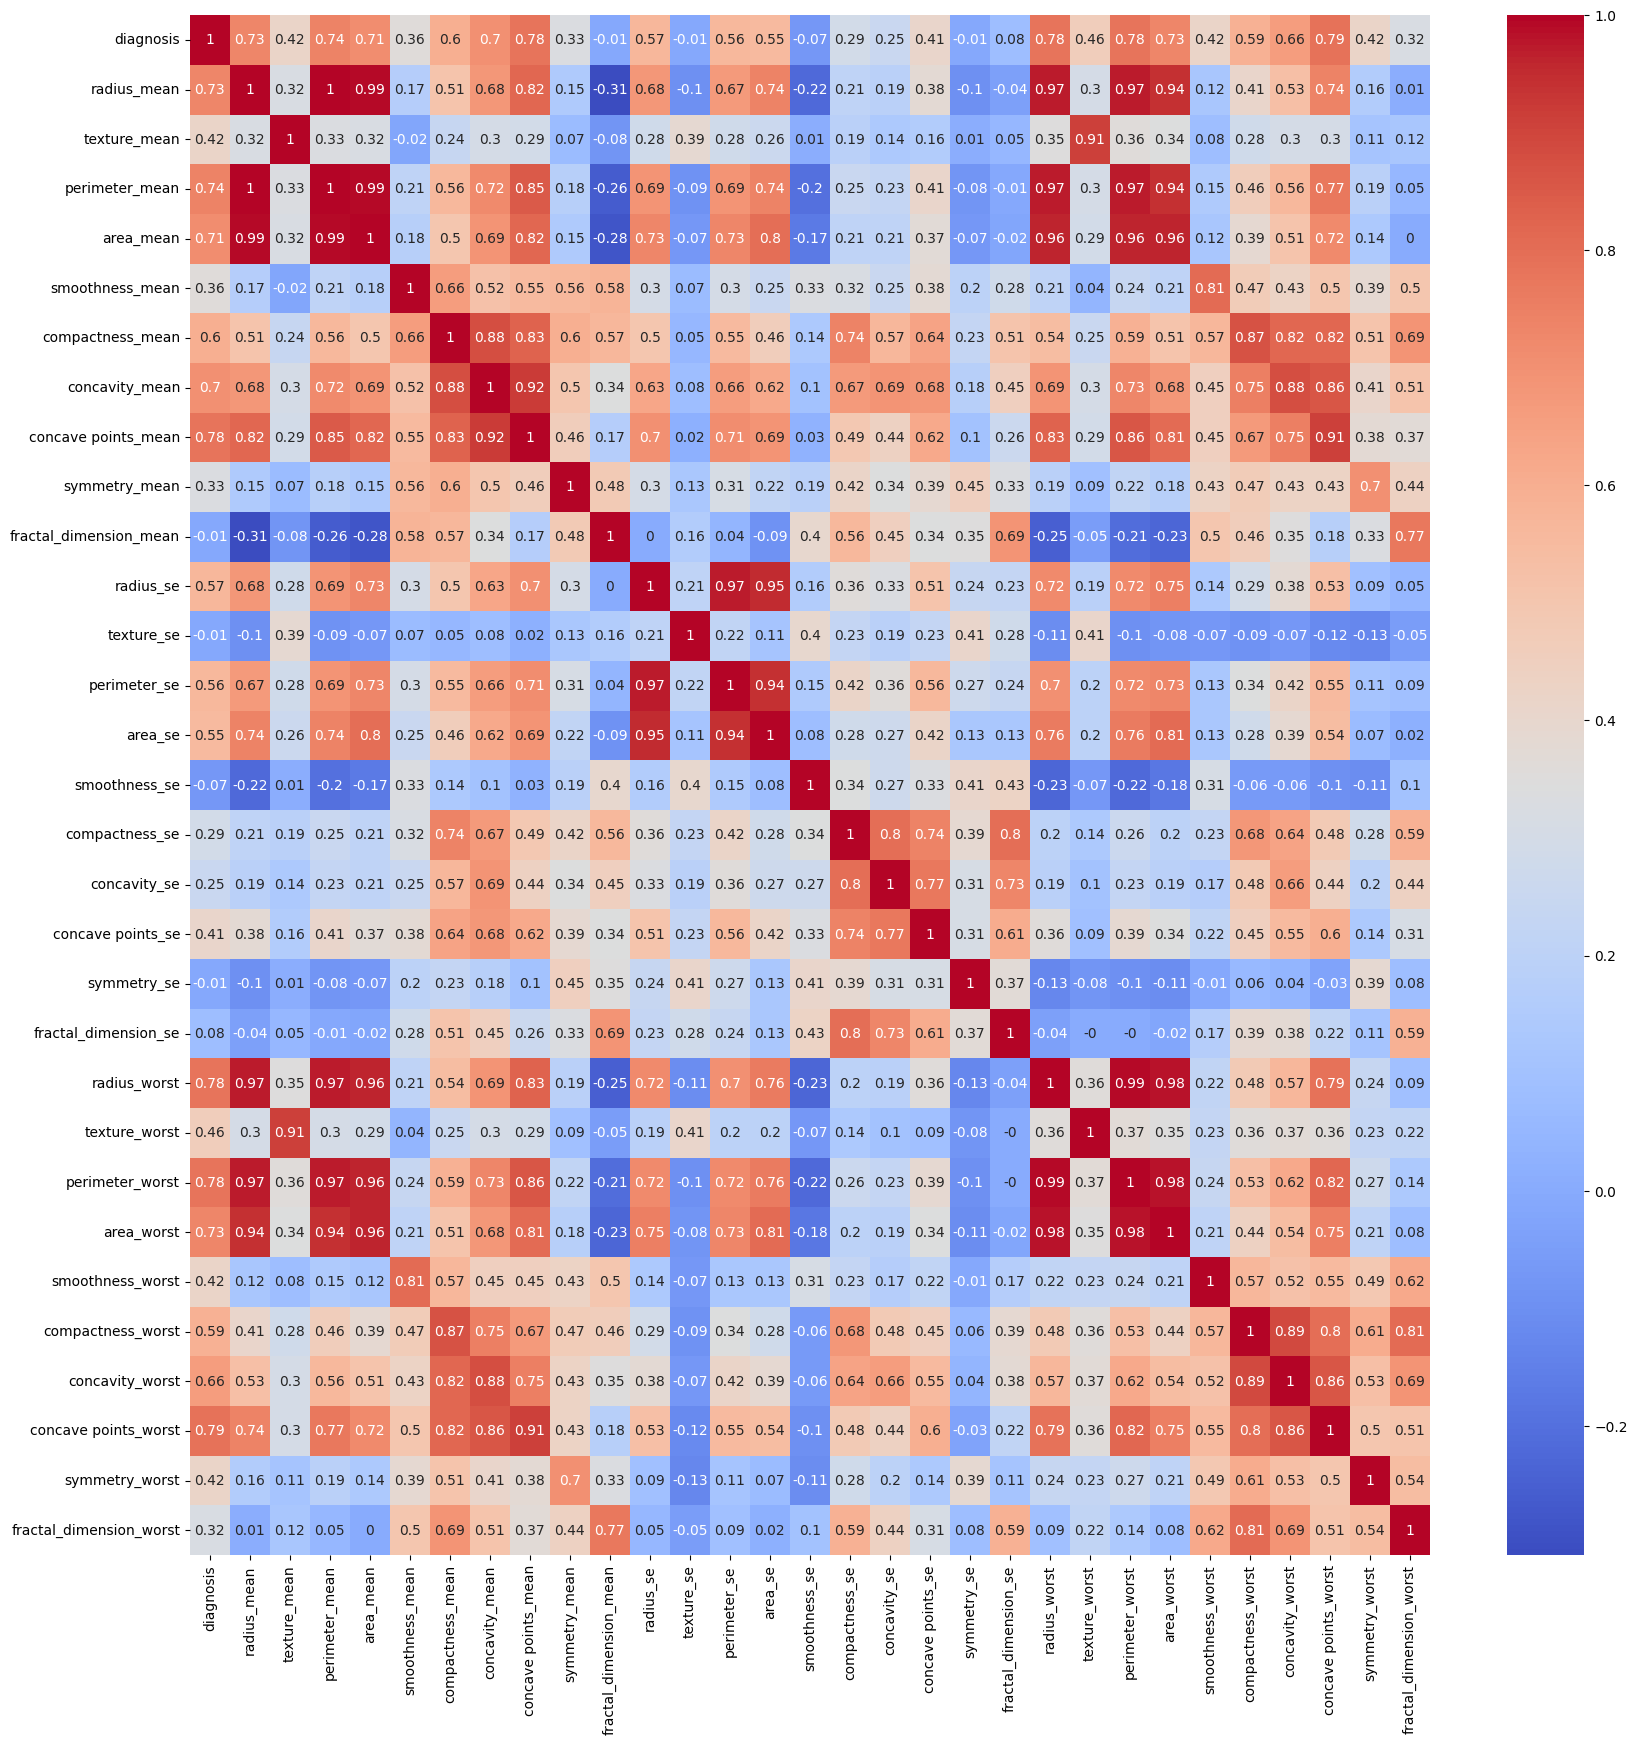

In [328]:
plt.figure(figsize=(20,20))
correlation = cancer.corr().round(2)

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()


# Independent & dependent varialbe

In [307]:
X = cancer.drop(['diagnosis'], axis=1)
y = cancer['diagnosis']

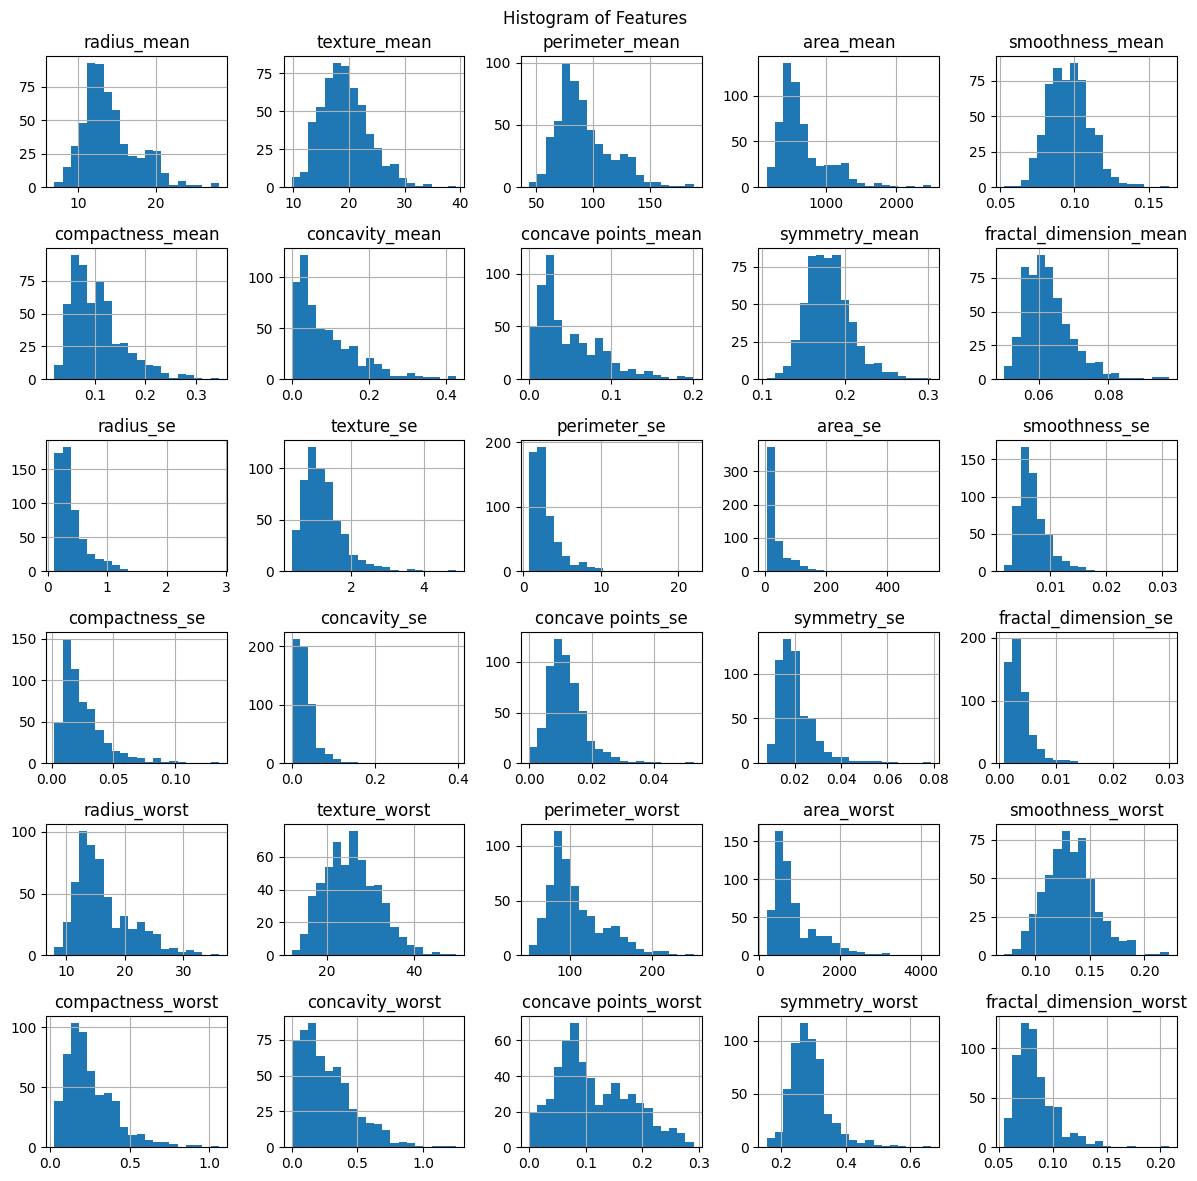

In [308]:
X.hist(bins=20, figsize=(12,12))
plt.suptitle('Histogram of Features')
plt.tight_layout()
plt.show()

In [309]:
type(X)

pandas.core.frame.DataFrame

In [310]:
type(y)

pandas.core.series.Series

In [311]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4, random_state=42)


In [312]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((341, 30), (228, 30), (341,), (228,))

In [313]:
y_test.value_counts()


,count
diagnosis,
0,148
1,80


# SCALING

In [314]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)
#

In [315]:
X_train,X_test

(array([[-0.93158266, -1.58538382, -0.96082569, ..., -1.29685162,
         -1.15903886, -0.96557241],
        [-0.55984676,  0.73956333, -0.59548627, ..., -0.80908172,
          0.35905959, -0.08051317],
        [-0.42113933, -0.58305279, -0.42049516, ..., -0.54353364,
          0.3130566 ,  0.12032719],
        ...,
        [ 0.00607953, -0.55540228, -0.10567281, ..., -1.27526614,
         -0.65935128, -1.2622942 ],
        [-0.07991907,  0.08977632, -0.07253362, ...,  1.04431968,
          0.48437806,  1.25104711],
        [-0.5792658 ,  0.29715515, -0.63428338, ..., -0.63888248,
         -0.28498218, -0.83224618]]),
 array([[-0.49881549, -0.14525303, -0.47788255, ..., -0.2166455 ,
          0.22263695,  0.22982491],
        [ 1.29605858,  0.47918768,  1.2401018 , ...,  0.985309  ,
         -0.51182448, -0.99620908],
        [ 0.33065491,  0.05751739,  0.35504282, ...,  0.55825798,
         -0.05813988, -0.18490477],
        ...,
        [-1.33244711,  0.41006141, -1.32576096, ..., -

# MLP

In [316]:
mlp=MLPClassifier(hidden_layer_sizes=(80,20), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(80, 20), max_iter=1000, random_state=42)

In [317]:
pred_mlp = mlp.predict(X_test)

In [318]:
print(classification_report(y_test, pred_mlp))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       148
           1       0.94      0.97      0.96        80

    accuracy                           0.97       228
   macro avg       0.96      0.97      0.97       228
weighted avg       0.97      0.97      0.97       228



In [319]:
mlp_cf = confusion_matrix(y_test, pred_mlp)
mlp_cf

array([[143,   5],
       [  2,  78]])

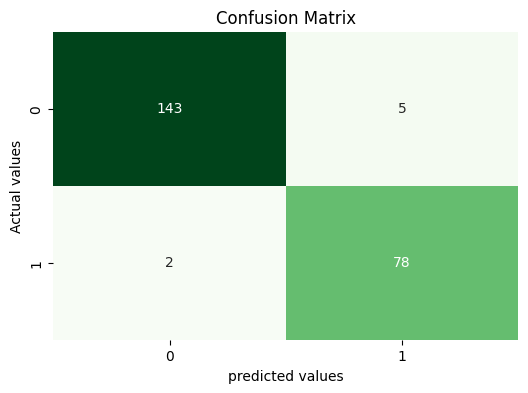

In [320]:
plt.figure(figsize=(6,4))

sns.heatmap(mlp_cf, annot= True, fmt='d', cmap= 'Greens',cbar= False)
plt.xlabel('predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix')
plt.show()

In [321]:
acc_mlp = accuracy_score(y_test, pred_mlp)
print(acc_mlp )

0.9692982456140351


# SVM

In [322]:
svm_cf = svm.SVC()
svm_cf.fit(X_train, y_train)
Pred_clf = svm_cf.predict(X_test)


print (classification_report(y_test, Pred_clf))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       148
           1       0.95      0.97      0.96        80

    accuracy                           0.97       228
   macro avg       0.97      0.97      0.97       228
weighted avg       0.97      0.97      0.97       228



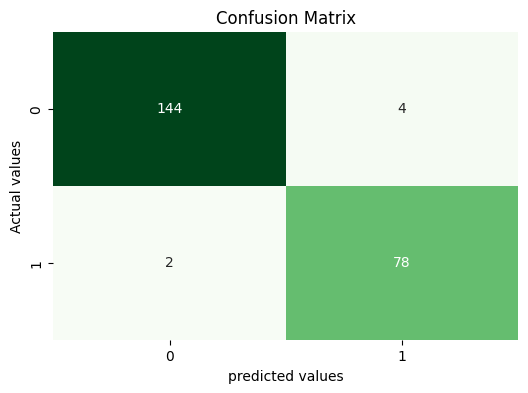

In [323]:
svm_cm= confusion_matrix(y_test, Pred_clf)

plt.figure(figsize=(6,4))

sns.heatmap(svm_cm, annot= True, fmt='d', cmap= 'Greens',cbar= False)
plt.xlabel('predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix')
plt.show()

In [324]:
acc_svm = accuracy_score(y_test, Pred_clf)
print(acc_svm)

0.9736842105263158
